# Basic visibility analysis using DEFRA LiDAR

This uses the exact same methods as in the folder `version_1_lidar_analysis` except is testing hex gridding of the points for analysis!

In [1]:
# Import required libraries
import laspy
import rasterio
from rasterio.transform import from_bounds
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy.interpolate import griddata
from scipy.ndimage import generic_filter
import pdal
import json
from pathlib import Path
import datetime

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile

import glob
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union

## Configuration

Setting up paths, parameters, etc.

Note: generally these will be kept consistent for batch processing, in order to make this more modular (e.g. all LiDAR tiles should be put in the same folder)

In [2]:
park_gdf= gpd.read_file("../../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
lidar_dir= "../../example_datasets"
OUTPUT_DIR = Path("../../outputs/method_02_hex")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Analysis parameters
GRID_SPACING = 10  # meters between analysis points
OBSERVER_HEIGHT = 1.0  # meters (eye height)
MAX_DISTANCE = 100  # maximum visibility distance in meters
MIN_VEG_AREA = 2  # minimum vegetation polygon area in sq meters

FILE_NAME = f"Woodhouse_Moor_{GRID_SPACING}_m_grid"


## CRS

All analyses use EPSG:27700 (British National Grid) for accurate distance-based calculations (viewshed, intervisibility, grid spacing). Reproject all datasets to this CRS early in the pipeline.


In [3]:
# Normalize CRS to EPSG:27700 (British National Grid)
TARGET_CRS = 'EPSG:27700'

print(f"Original park CRS: {park_gdf.crs}")

# Reproject park to target CRS if needed
if park_gdf.crs != TARGET_CRS:
    park_gdf = park_gdf.to_crs(TARGET_CRS)
    print(f"Reprojected park to {TARGET_CRS}")
else:
    print(f"Park already in {TARGET_CRS}")

# Extract park boundary geometry (now in EPSG:27700)
park_boundary = park_gdf.geometry.iloc[0]
print(f"Park boundary CRS: {park_gdf.crs}")


Original park CRS: EPSG:4326
Reprojected park to EPSG:27700
Park boundary CRS: EPSG:27700


Load in the LiDAR data. In this case, all the files we want to work with are present in a single folder; there is no need to filter for grid reference etc.

- Can build in a search functionality for batch processing
    - See previous iteration of this from work Dec 2025 repo

In [4]:
def load_lidar_rasters_for_park(lidar_dir, park_geometry):
    """
    Load and mosaic DSM and DTM rasters from UK National LiDAR Programme
    Handles multiple tiles, CRS mismatches, missing CRS and NoData values
    """
    
    
    # Find DSM and DTM files
    dsm_files = (glob.glob(f"{lidar_dir}/*DSM*.tif") + 
                 glob.glob(f"{lidar_dir}/*dsm*.tif") +
                 glob.glob(f"{lidar_dir}/*FirstReturn*.tif"))
    
    dtm_files = (glob.glob(f"{lidar_dir}/*DTM*.tif") + 
                 glob.glob(f"{lidar_dir}/*dtm*.tif"))
    
    if not dsm_files or not dtm_files:
        print(f"ERROR: Missing files in {lidar_dir}")
        print(f"DSM files found: {len(dsm_files)}")
        print(f"DTM files found: {len(dtm_files)}")
        return None
    
    print(f"Loading {len(dsm_files)} DSM and {len(dtm_files)} DTM files")
    
    # Handle both GeoDataFrame and geometry inputs
    if isinstance(park_geometry, gpd.GeoDataFrame):
        park_gdf = park_geometry.copy()
        park_geom_single = park_geometry.geometry.iloc[0]
    else:
        park_geom_single = park_geometry
        if hasattr(park_geometry, 'crs'):
            park_gdf = gpd.GeoDataFrame([1], geometry=[park_geometry], crs=park_geometry.crs)
        else:
            # Assume WGS84 (lat/lon) if no CRS provided
            park_gdf = gpd.GeoDataFrame([1], geometry=[park_geometry], crs='EPSG:4326')
    
    # Find the raster CRS by checking all files
    raster_crs = None
    for dsm_file in dsm_files:
        with rasterio.open(dsm_file) as src:
            if src.crs is not None:
                raster_crs = src.crs
                break
    
    # If no DSM has CRS, check DTM files
    if raster_crs is None:
        for dtm_file in dtm_files:
            with rasterio.open(dtm_file) as src:
                if src.crs is not None:
                    raster_crs = src.crs
                    break
    
    # If still no CRS found, use park's CRS
    if raster_crs is None:
        raster_crs = park_gdf.crs
        print(f"WARNING: No CRS found in any raster. Assigning park CRS {raster_crs}")
    else:
        # Reproject park if needed
        if park_gdf.crs is not None and park_gdf.crs.to_string() != raster_crs.to_string():
            print(f"Reprojecting park geometry to match raster CRS {raster_crs}")
            park_gdf = park_gdf.to_crs(raster_crs)
            park_geom_single = park_gdf.geometry.iloc[0]
    
    # Function to mosaic multiple rasters with NoData handling
    def mosaic_rasters(file_list, target_crs=None):
        # Use the provided target_crs (from parent function level)
        # If not provided, determine from first raster that has one
        if target_crs is None:
            for f in file_list:
                with rasterio.open(f) as src:
                    if src.crs is not None:
                        target_crs = src.crs
                        break
        
        # If still no CRS found, use the park's CRS
        if target_crs is None:
            target_crs = park_gdf.crs
            print(f"WARNING: No CRS found in rasters. Assigning {target_crs}")
        
        if len(file_list) == 1:
            with rasterio.open(file_list[0]) as src:
                data = src.read(1)
                # Replace NoData values with NaN
                if src.nodata is not None:
                    data = np.where(data == src.nodata, np.nan, data)
                # Also handle extreme values
                data = np.where(data < -1000, np.nan, data)
                # Create output metadata
                out_meta = src.meta.copy()
                if out_meta['crs'] is None:
                    out_meta['crs'] = target_crs
                    print(f"WARNING: {file_list[0]} has no CRS. Assigning {target_crs}")
                return data, src.transform, out_meta
        
        # For multiple files, open and ensure all have CRS
        # Use memory files to normalize CRS before merging
        normalized_files = []
        
        for f in file_list:
            with rasterio.open(f) as src:
                src_crs = src.crs if src.crs is not None else target_crs
                if src.crs is None:
                    print(f"WARNING: {f} has no CRS. Assigning {target_crs}")
                
                # Write to memory file with target CRS
                memfile = MemoryFile()
                out_meta = src.meta.copy()
                out_meta['crs'] = src_crs
                
                with memfile.open(**out_meta) as mem_dst:
                    mem_dst.write(src.read())
                
                # Re-open the memory file
                mem_dst = memfile.open()
                normalized_files.append((mem_dst, memfile))
        
        try:
            # Extract the dataset objects for merging
            src_datasets = [mem_dst for mem_dst, _ in normalized_files]
            
            mosaic, out_transform = merge(src_datasets, nodata=np.nan)
            
            # Clean up NoData values
            mosaic = mosaic[0]
            mosaic = np.where(mosaic < -1000, np.nan, mosaic)
            
            out_meta = src_datasets[0].meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": mosaic.shape[0],
                "width": mosaic.shape[1],
                "transform": out_transform,
                "nodata": np.nan,
                "crs": target_crs
            })
            return mosaic, out_transform, out_meta
        finally:
            for mem_dst, memfile in normalized_files:
                mem_dst.close()
                memfile.close()
    
    # Mosaic and clip DSM
    dsm_mosaic, dsm_transform, dsm_meta = mosaic_rasters(dsm_files, target_crs=raster_crs)
    
    # Check for valid data
    valid_dsm = np.sum(~np.isnan(dsm_mosaic))
    print(f"DSM valid pixels: {valid_dsm} of {dsm_mosaic.size} ({valid_dsm/dsm_mosaic.size*100:.1f}%)")
    
    with MemoryFile() as memfile:
        with memfile.open(**dsm_meta) as dataset:
            dataset.write(dsm_mosaic, 1)
            park_geom_list = [park_geom_single.__geo_interface__]
            
            try:
                dsm_clipped, dsm_clip_transform = mask(dataset, park_geom_list, crop=True, nodata=np.nan)
                dsm_clipped = dsm_clipped[0]
            except ValueError as e:
                print(f"ERROR clipping DSM: {e}")
                print(f"Park bounds: {park_gdf.total_bounds}")
                print(f"Park CRS: {park_gdf.crs}, Raster CRS: {raster_crs}")
                return None
    
    # Mosaic and clip DTM
    dtm_mosaic, dtm_transform, dtm_meta = mosaic_rasters(dtm_files, target_crs=raster_crs)
    
    # Check for valid data
    valid_dtm = np.sum(~np.isnan(dtm_mosaic))
    print(f"DTM valid pixels: {valid_dtm} of {dtm_mosaic.size} ({valid_dtm/dtm_mosaic.size*100:.1f}%)")
    
    with MemoryFile() as memfile:
        with memfile.open(**dtm_meta) as dataset:
            dataset.write(dtm_mosaic, 1)
            park_geom_list = [park_geom_single.__geo_interface__]
            dtm_clipped, dtm_clip_transform = mask(dataset, park_geom_list, crop=True, nodata=np.nan)
            dtm_clipped = dtm_clipped[0]
    
    # Calculate height above ground
    height_above_ground = dsm_clipped - dtm_clipped
    
    # Report statistics
    valid_height = ~np.isnan(height_above_ground)
    if np.sum(valid_height) > 0:
        height_range = f"{np.nanmin(height_above_ground):.1f}m to {np.nanmax(height_above_ground):.1f}m"
    else:
        height_range = "No valid data"
    
    print(f"Output shape: {dsm_clipped.shape}, Height range: {height_range}")
    
    # Update metadata for clipped rasters
    dsm_meta.update({
        "height": dsm_clipped.shape[0],
        "width": dsm_clipped.shape[1],
        "transform": dsm_clip_transform,
        "nodata": np.nan
    })
    
    dtm_meta.update({
        "height": dtm_clipped.shape[0],
        "width": dtm_clipped.shape[1],
        "transform": dtm_clip_transform,
        "nodata": np.nan
    })
    
    return {
        'dsm': dsm_clipped,
        'dtm': dtm_clipped,
        'height_above_ground': height_above_ground,
        'dsm_meta': dsm_meta,
        'dtm_meta': dtm_meta,
        'transform': dsm_clip_transform,
        'crs': raster_crs
    }

In [5]:
lidar_data = load_lidar_rasters_for_park(lidar_dir, park_gdf)


Loading 2 DSM and 2 DTM files
DSM valid pixels: 50000000 of 50000000 (100.0%)
DTM valid pixels: 50000000 of 50000000 (100.0%)
Output shape: (698, 560), Height range: -0.2m to 24.5m


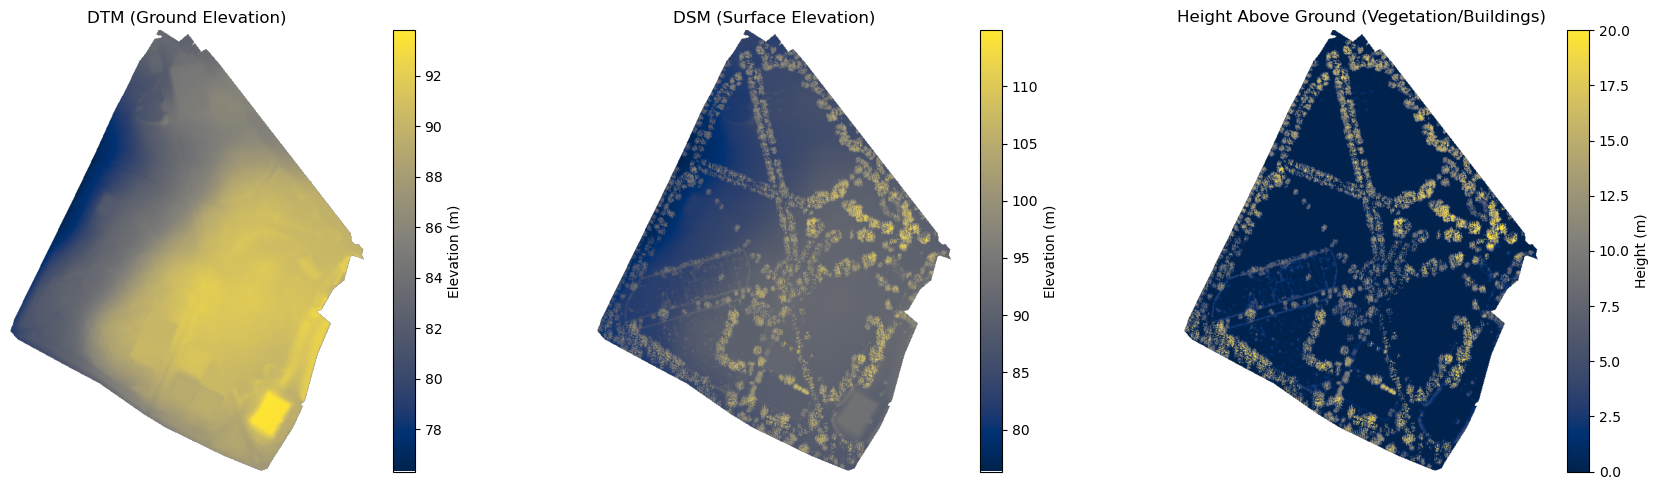

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DTM
im1 = axes[0].imshow(lidar_data['dtm'], cmap='cividis', origin='upper')
axes[0].set_title('DTM (Ground Elevation)')
plt.colorbar(im1, ax=axes[0], label='Elevation (m)')
axes[0].axis('off')

# DSM
im2 = axes[1].imshow(lidar_data['dsm'], cmap='cividis', origin='upper')
axes[1].set_title('DSM (Surface Elevation)')
plt.colorbar(im2, ax=axes[1], label='Elevation (m)')
axes[1].axis('off')

# Height above ground
im3 = axes[2].imshow(lidar_data['height_above_ground'], 
                     cmap='cividis', origin='upper', vmin=0, vmax=20)
axes[2].set_title('Height Above Ground (Vegetation/Buildings)')
plt.colorbar(im3, ax=axes[2], label='Height (m)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
def create_analysis_grid(park_geometry, spacing=10):
    """
    Create a regular grid of points within park boundary
    
    Parameters:
    park_geometry: shapely geometry of park
    spacing: distance between grid points in meters
    """
    bounds = park_geometry.bounds
    
    # Create grid
    x_coords = np.arange(bounds[0], bounds[2], spacing)
    y_coords = np.arange(bounds[1], bounds[3], spacing)
    
    # Create all point combinations
    points = []
    for x in x_coords:
        for y in y_coords:
            point = Point(x, y)
            if park_geometry.contains(point):
                points.append(point)
    
    grid_gdf = gpd.GeoDataFrame(geometry=points, crs='EPSG:27700')
    print(f"Created {len(grid_gdf)} analysis points with {spacing}m spacing")
    
    return grid_gdf

In [9]:
def create_analysis_grid_hex(park_geometry, spacing=10):
    """
    Create a hexagonal grid of points within park boundary
    
    Parameters:
    park_geometry: shapely geometry of park
    spacing: distance to nearest neighbors in hex grid (meters)
    
    Returns:
    GeoDataFrame with hex grid points
    """
    bounds = park_geometry.bounds
    
    # For a regular hexagonal grid with circumradius = spacing
    # Horizontal spacing between hex centers: 1.5 * spacing
    # Vertical spacing: spacing * sqrt(3) / 2
    h_spacing = 1.5 * spacing
    v_spacing = spacing * np.sqrt(3) / 2
    
    points = []
    
    # Generate hexagonal grid
    x_min, y_min, x_max, y_max = bounds
    
    # Create alternating rows
    y = y_min
    row = 0
    
    while y <= y_max:
        x = x_min
        
        # Offset every other row by h_spacing/2
        if row % 2 == 1:
            x += h_spacing / 2
        
        while x <= x_max:
            point = Point(x, y)
            if park_geometry.contains(point):
                points.append(point)
            x += h_spacing
        
        y += v_spacing
        row += 1
    
    grid_gdf = gpd.GeoDataFrame(geometry=points, crs='EPSG:27700')
    print(f"Created {len(grid_gdf)} analysis points with hexagonal spacing (~{spacing}m to nearest neighbors)")
    
    return grid_gdf

In [11]:
# Create analysis grid
# Park boundary is now guaranteed to be in EPSG:27700
# square grid spacing: "Created 2185 analysis points with 10m spacing"
# hex: "Created 1685 analysis points with hexagonal spacing (~10m to nearest neighbors)"
analysis_points = create_analysis_grid_hex(park_boundary, spacing=GRID_SPACING)


Created 1685 analysis points with hexagonal spacing (~10m to nearest neighbors)


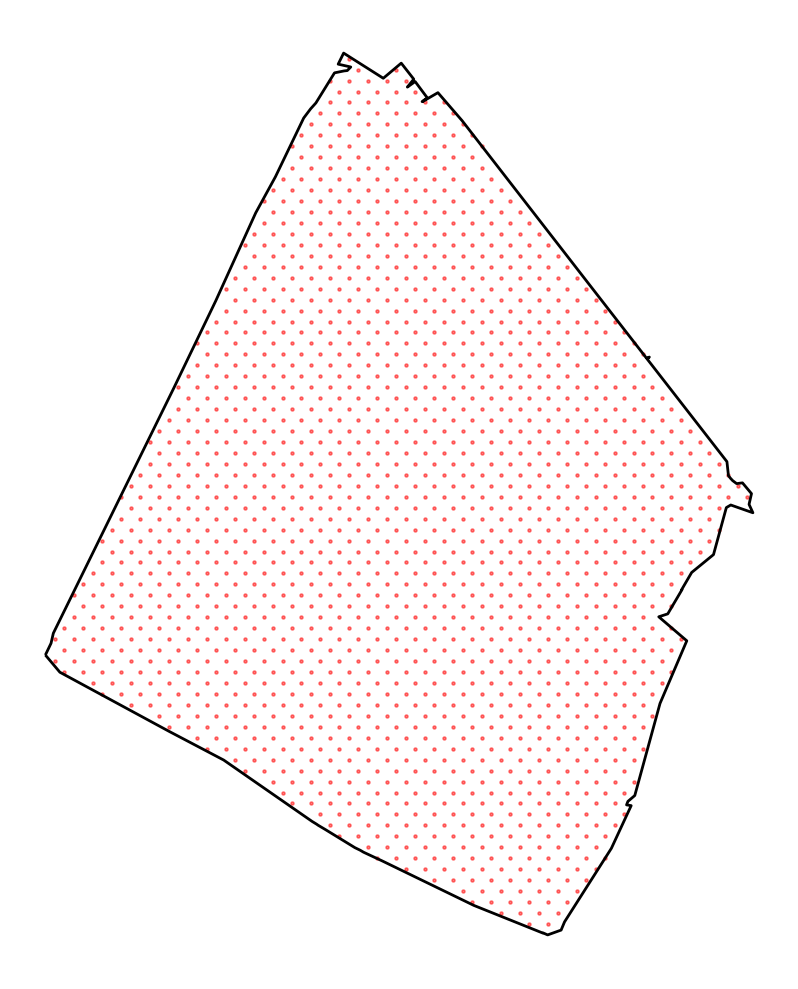

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))
park_gdf.boundary.plot(ax=ax, color='black', linewidth=2)
analysis_points.plot(ax=ax, color='red', markersize=5, alpha=0.5)
ax.axis('off')
plt.tight_layout()
plt.show()

In [13]:
def point_to_raster_index(point, transform):
    """Convert a point to raster row/col indices"""
    from rasterio.transform import rowcol
    row, col = rowcol(transform, point.x, point.y)
    return int(row), int(col)

def get_elevation_at_point(point, raster, transform):
    """Get elevation value at a point from raster"""
    row, col = point_to_raster_index(point, transform)
    
    # Check bounds
    if 0 <= row < raster.shape[0] and 0 <= col < raster.shape[1]:
        return raster[row, col]
    return np.nan

In [14]:
def check_line_of_sight(observer_point, target_point, dsm, dtm, transform, 
                        observer_height=1.0, target_height=0):
    """
    Check if there is line of sight between two points
    
    Parameters:
    observer_point: Point geometry of observer
    target_point: Point geometry of target
    dsm: Digital Surface Model array
    dtm: Digital Terrain Model array  
    transform: rasterio transform
    observer_height: height of observer above ground (meters)
    target_height: height of target above ground (meters)
    
    Returns:
    bool: True if visible, False if blocked
    """
    # Get observer and target elevations
    obs_ground = get_elevation_at_point(observer_point, dtm, transform)
    target_ground = get_elevation_at_point(target_point, dtm, transform)
    
    if np.isnan(obs_ground) or np.isnan(target_ground):
        return False
    
    obs_elevation = obs_ground + observer_height
    target_elevation = target_ground + target_height
    
    # Calculate distance and number of sample points
    distance = observer_point.distance(target_point)
    
    if distance < 1:
        return True
    
    # Sample points along the line (every meter)
    num_samples = int(distance) + 1
    
    # Create line samples
    x_samples = np.linspace(observer_point.x, target_point.x, num_samples)
    y_samples = np.linspace(observer_point.y, target_point.y, num_samples)
    
    # Required height at each sample point (linear interpolation)
    required_heights = np.linspace(obs_elevation, target_elevation, num_samples)
    
    # Check each sample point
    for i in range(1, num_samples - 1):  # Skip start and end points
        sample_point = Point(x_samples[i], y_samples[i])
        
        # Get surface elevation at this point
        surface_elevation = get_elevation_at_point(sample_point, dsm, transform)
        
        if np.isnan(surface_elevation):
            continue
        
        # Check if surface blocks the line of sight
        if surface_elevation > required_heights[i]:
            return False
    
    return True

In [15]:
def calculate_visibility_metrics(analysis_points, dsm, dtm, transform, 
                                 observer_height=1.0, target_height=0, max_distance=250):
    """
    Calculate visibility metrics for all analysis points
    
    Parameters:
    analysis_points: GeoDataFrame of analysis points
    dsm: Digital Surface Model
    dtm: Digital Terrain Model
    transform: rasterio transform
    observer_height: observer eye height in meters; default 1 m
    max_distance: maximum visibility distance in meters
    
    Returns:
    GeoDataFrame with visibility metrics
    """
    print(f"Calculating visibility for {len(analysis_points)} points")
    
    results = []
    
    for idx, observer_row in analysis_points.iterrows():
        if idx % 50 == 0:
            print(f"Processing point {idx+1}/{len(analysis_points)}")
        
        observer_point = observer_row.geometry
        visible_count = 0
        total_checked = 0
        
        # Check visibility to all other points within max_distance
        for target_idx, target_row in analysis_points.iterrows():
            if idx == target_idx:
                continue
            
            target_point = target_row.geometry
            distance = observer_point.distance(target_point)
            
            if distance > max_distance:
                continue
            
            total_checked += 1
            
            if check_line_of_sight(observer_point, target_point, dsm, dtm, 
                                  transform, observer_height, target_height):
                visible_count += 1
        
        # Calculate visibility percentage
        if total_checked > 0:
            visibility_pct = (visible_count / total_checked) * 100
        else:
            visibility_pct = 0
        
        results.append({
            'geometry': observer_point,
            'visible_points': visible_count,
            'total_points': total_checked,
            'visibility_pct': visibility_pct
        })
    
    results_gdf = gpd.GeoDataFrame(results, crs=analysis_points.crs)

    
    return results_gdf

In [17]:
visibility_results_2 = calculate_visibility_metrics(
    analysis_points, 
    lidar_data['dsm'], 
    lidar_data['dtm'], 
    lidar_data['transform'],
    observer_height=1.0,
    target_height=0,
    max_distance=100
)

Calculating visibility for 1685 points
Processing point 1/1685
Processing point 51/1685
Processing point 101/1685
Processing point 151/1685
Processing point 201/1685
Processing point 251/1685
Processing point 301/1685
Processing point 351/1685
Processing point 401/1685
Processing point 451/1685
Processing point 501/1685
Processing point 551/1685
Processing point 601/1685
Processing point 651/1685
Processing point 701/1685
Processing point 751/1685
Processing point 801/1685
Processing point 851/1685
Processing point 901/1685
Processing point 951/1685
Processing point 1001/1685
Processing point 1051/1685
Processing point 1101/1685
Processing point 1151/1685
Processing point 1201/1685
Processing point 1251/1685
Processing point 1301/1685
Processing point 1351/1685
Processing point 1401/1685
Processing point 1451/1685
Processing point 1501/1685
Processing point 1551/1685
Processing point 1601/1685
Processing point 1651/1685


This took 3 mins 17 s in comp to 5 mins 41 s for sqaure grid.

<Axes: >

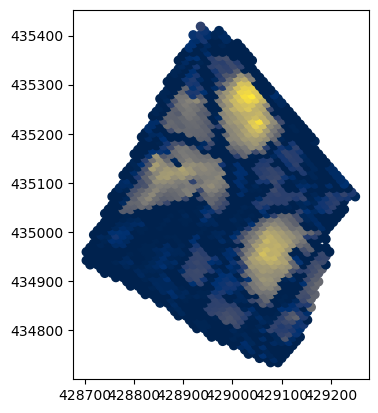

In [19]:
visibility_results_2.plot(column='visibility_pct', cmap="cividis")

In [22]:
visibility_results_2.to_file(OUTPUT_DIR / f'{FILE_NAME}_100m_vis_hex.geojson', driver='GeoJSON')

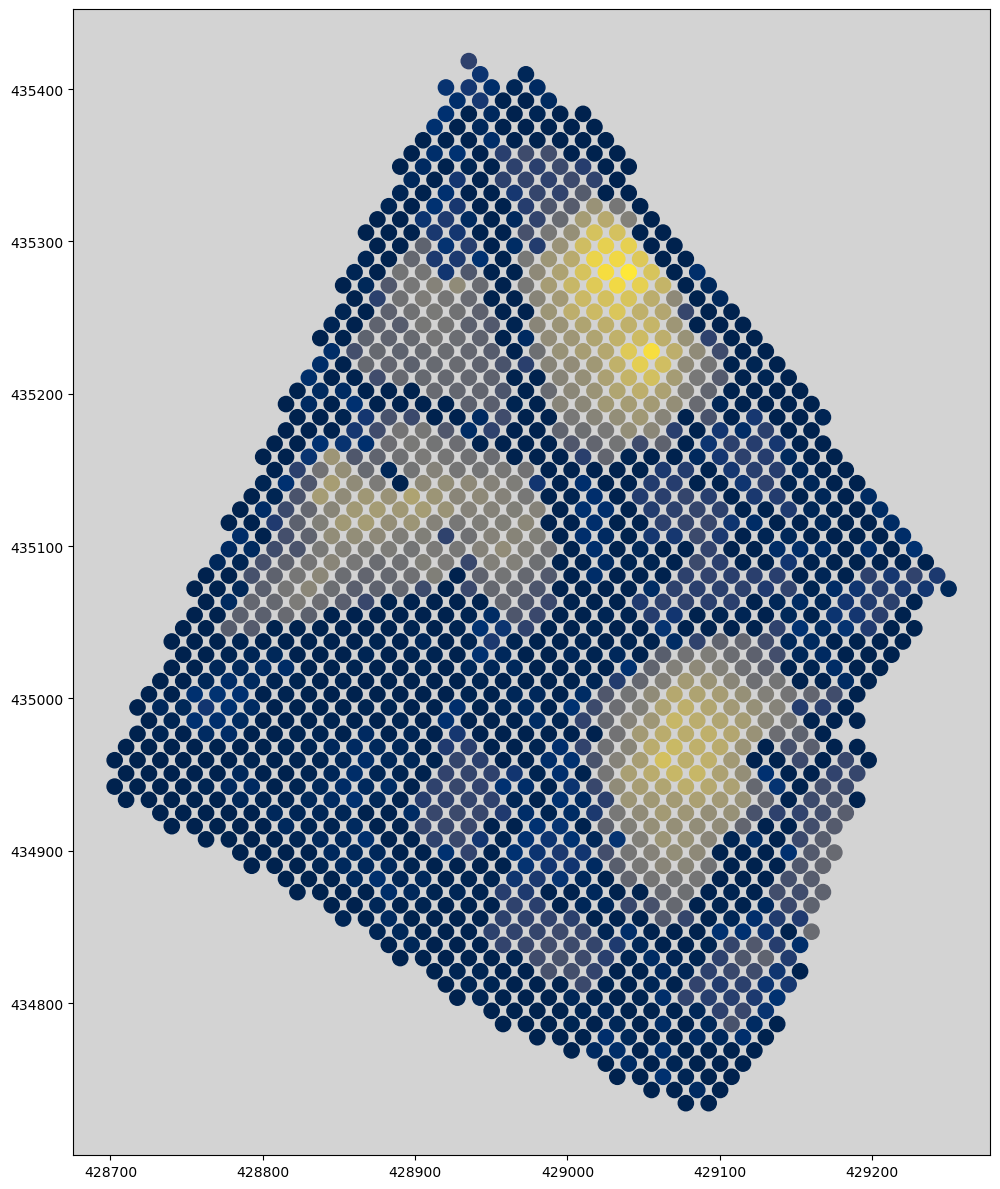

In [27]:
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('lightgrey')
visibility_results_2.plot(column='visibility_pct', cmap="cividis", ax=ax, markersize=120)
plt.tight_layout()
plt.show()